# Simulating a Malware Outbreak on a College Network

**Motivation.** We use an SEIR agent-based model on a Barabasi-Albert (scale-free) network to mimic a campus where highly connected hub nodes (servers) coexist with less connected student laptops. The goal is to study how malware propagates and how smart defenses flatten the curve.

**Data source.** All data are synthetic, generated by mechanistic simulation calibrated to common malware/ransomware parameters (e.g., multi-day incubation before activation).


In [19]:
import random
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from models import UniversityNetwork

# Global defaults so you can tune the experiment quickly
NUM_AGENTS = 1000
INITIAL_OUTBREAK = 10
AVG_INCUBATION = 4
BASE_VIRUS_SPREAD = 0.3
PATCHING_RATE_DEFAULT = 0.10
RNG_SEED = 42

random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
plt.style.use("ggplot")


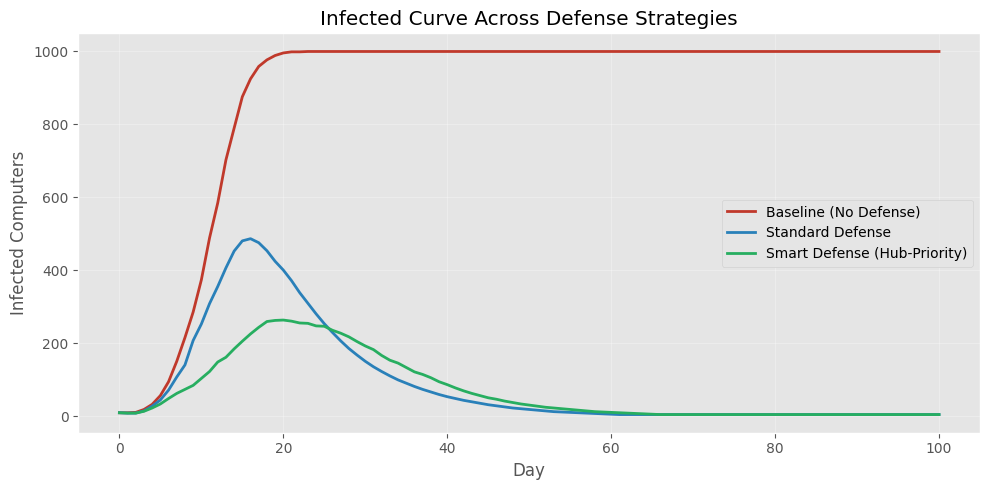

In [20]:
def run_single_scenario(patching_strategy: str, patching_rate: float, title: str, steps: int = 100) -> pd.DataFrame:
    """Run one scenario with the shared UniversityNetwork model."""
    model = UniversityNetwork(
        patching_strategy=patching_strategy,
        patching_rate=patching_rate,
        num_agents=NUM_AGENTS,
        initial_outbreak_size=INITIAL_OUTBREAK,
        avg_incubation_time=AVG_INCUBATION,
        virus_spread_chance=BASE_VIRUS_SPREAD,
        seed=RNG_SEED,
    )
    for _ in range(steps):
        model.step()
    df = model.datacollector.get_model_vars_dataframe()
    df["Title"] = title
    return df


# Define the three scenarios
SCENARIO_A = ("Baseline (No Defense)", 0.0, "Random")
SCENARIO_B = ("Standard Defense", 0.10, "Random")
SCENARIO_C = ("Smart Defense (Hub-Priority)", 0.10, "Targeted")

# Run scenarios
history_a = run_single_scenario(SCENARIO_A[2], SCENARIO_A[1], SCENARIO_A[0])
history_b = run_single_scenario(SCENARIO_B[2], SCENARIO_B[1], SCENARIO_B[0])
history_c = run_single_scenario(SCENARIO_C[2], SCENARIO_C[1], SCENARIO_C[0])

# Plot infected curves together
plt.figure(figsize=(10, 5))
for history, color in zip([history_a, history_b, history_c], ["#c0392b", "#2980b9", "#27ae60"]):
    plt.plot(history.index, history["Infected"], label=history["Title"].iloc[0], linewidth=2, color=color)
plt.xlabel("Day")
plt.ylabel("Infected Computers")
plt.title("Infected Curve Across Defense Strategies")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


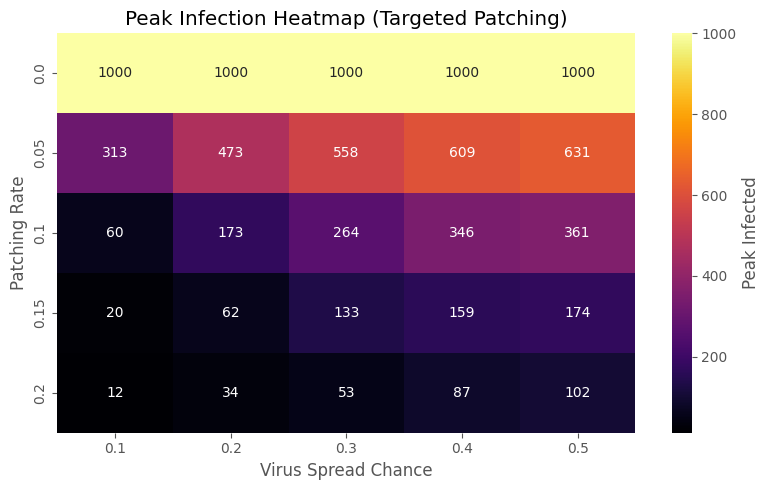

In [21]:
def sweep_peak_infections(
    patching_rates: List[float], infection_probs: List[float], steps: int = 120
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for patch in patching_rates:
        for prob in infection_probs:
            model = UniversityNetwork(
                patching_strategy="Targeted",
                patching_rate=patch,
                num_agents=NUM_AGENTS,
                initial_outbreak_size=INITIAL_OUTBREAK,
                avg_incubation_time=AVG_INCUBATION,
                virus_spread_chance=prob,
                seed=RNG_SEED,
            )
            for _ in range(steps):
                model.step()
            history = model.datacollector.get_model_vars_dataframe()
            rows.append({
                "PatchingRate": patch,
                "VirusSpreadChance": prob,
                "PeakInfection": history["Infected"].max(),
            })
    df = pd.DataFrame(rows)
    pivot = df.pivot(index="PatchingRate", columns="VirusSpreadChance", values="PeakInfection")
    return df, pivot

patch_grid = [0.00, 0.05, 0.10, 0.15, 0.20]
prob_grid = [0.10, 0.20, 0.30, 0.40, 0.50]

_, peak_pivot = sweep_peak_infections(patch_grid, prob_grid)
plt.figure(figsize=(8, 5))
sns.heatmap(peak_pivot, annot=True, fmt=".0f", cmap="inferno", cbar_kws={"label": "Peak Infected"})
plt.title("Peak Infection Heatmap (Targeted Patching)")
plt.xlabel("Virus Spread Chance")
plt.ylabel("Patching Rate")
plt.tight_layout()
plt.show()


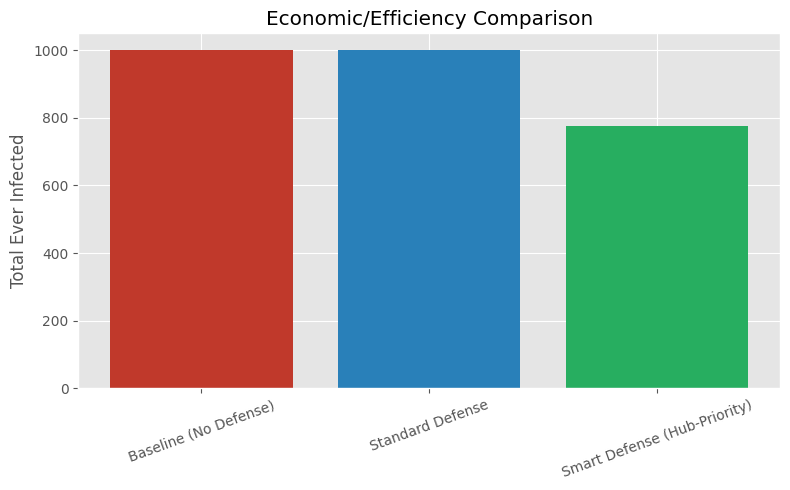

Targeted Defense reduced infections by 22.3% compared to Random Defense.


In [22]:
def total_infected(history: pd.DataFrame) -> float:
    # Approximate total ever infected as final (Recovered + Infected + Exposed).
    return float(history["Recovered"].iloc[-1] + history["Infected"].iloc[-1] + history["Exposed"].iloc[-1])


totals = {
    history_a["Title"].iloc[0]: total_infected(history_a),
    history_b["Title"].iloc[0]: total_infected(history_b),
    history_c["Title"].iloc[0]: total_infected(history_c),
}

plt.figure(figsize=(8, 5))
plt.bar(totals.keys(), totals.values(), color=["#c0392b", "#2980b9", "#27ae60"])
plt.ylabel("Total Ever Infected")
plt.title("Economic/Efficiency Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

reduction = 100 * (totals[history_b["Title"].iloc[0]] - totals[history_c["Title"].iloc[0]]) / totals[history_b["Title"].iloc[0]]
print(f"Targeted Defense reduced infections by {reduction:.1f}% compared to Random Defense.")


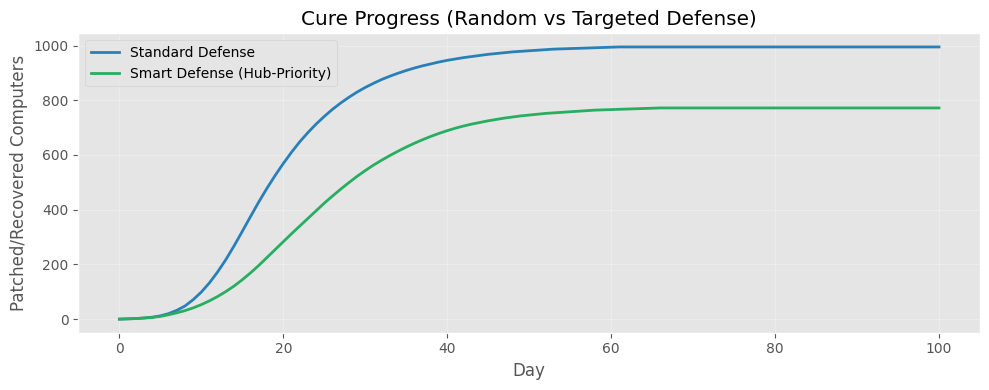

In [23]:
# Bonus: visualize how many machines are cured (Recovered) over time in the defense scenarios
plt.figure(figsize=(10, 4))
for history, color in zip([history_b, history_c], ["#2980b9", "#27ae60"]):
    plt.plot(history.index, history["Recovered"], label=history["Title"].iloc[0], linewidth=2, color=color)
plt.xlabel("Day")
plt.ylabel("Patched/Recovered Computers")
plt.title("Cure Progress (Random vs Targeted Defense)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
